In [1]:
import polars as pl
import bz2
import gzip as gz
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import Counter

# KEY EDA to do

Project will involeve the flows too and from each user and we will look at binning the flows.

1) Basic checks
    Checks for duplicates number of source and destination computers, time window etc.
2) Frequency checks
    Checks for the distributions of user sent and recieved signal activity, frequency by human and machine.
3) Do basic statistical tests for periodicity across users and in human and machine users. (randomly sample if necessary)
4) investigate the effects of binning

list 2
1) Invesitgate the flows too and from each user how many go from each machine in a given time period.
2) Investigate variance of a machines flows over time.
3) Investigate the effect of binning width has on machine flow bias and variance.
4) Aim to indentify both human and machine operated accounts.
5) Static clustering

#### Ideas
- Idea smooth the distribution of mus towards the other distribution. I.e. for each user we will have a value of mu for each bin. Then for each cluster we will have an average distribution of mus. We will smooth the lower tail of the mu for a user towards the average lower tail obsered in that cluster. This way we preserve the periodic structure for each user whilst smoothing extremes.
- Pick binning based on frequency periodicity analysis.

#### Questions
- How to bin
- How to handle multiple requests within the same time period
- How to handle low frequency users
- How to smooth
- How good is the human machine classification system I have seen human users exhibiting behaviour with high requests and periodicity that are often seen in machines is this just a normal upper tail human or a machine
- Should I be dealing with users or computers
- What are the anonymous logons in the dataset

### Flows to and from each user and distribution of user flows

In [2]:
# df = pl.scan_parquet("/home/ma/a/alb25/Project/thesis_code/data/raw/*")

df = pl.scan_parquet("/home/ma/a/alb25/Project/thesis_code/data/processed/auth_w_user_type.parquet")

In [ ]:
# Adding the user type columns


# def add_user_type(column):
#     return (pl.when(pl.col(column).str.contains(r"^U\d+@")).then(pl.lit("human"))
#         .when(pl.col(column).str.contains(r"^C\d+\$@")).then(pl.lit("machine"))
#         .when(pl.col(column).str.contains(r"^(SYSTEM|LOCAL SERVICE|NETWORK SERVICE)@")).then(pl.lit("system"))
#         .when(pl.col(column).str.contains(r"^ANONYMOUS LOGON@")).then(pl.lit("anon"))
#         .otherwise(pl.lit("other")))

# df = df.with_columns([add_user_type("source_user@domain").alias("source_user_type"),
#     add_user_type("destination_user@domain").alias("destination_user_type")])

In [5]:
# df.sink_parquet("/home/ma/a/alb25/Project/thesis_code/data/processed/auth_w_user_type.parquet")

In [3]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure,source_user_type,destination_user_type
str,str,str,str,str,str,str,str,str,str,str
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success""","""anon""","""anon"""
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success""","""anon""","""anon"""
"""1""","""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success""","""machine""","""machine"""
"""1""","""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success""","""machine""","""system"""
"""1""","""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success""","""machine""","""machine"""


## Basic Checks

In [3]:
destinations = df.select('destination_computer').unique().collect()['destination_computer'].to_list()

In [4]:
sources = df.select('source_computer').unique().collect()['source_computer'].to_list()

In [ ]:
len(destinations)

15620

In [7]:
len(sources)

16006

In [ ]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure
str,str,str,str,str,str,str,str,str
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
"""1""","""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


In [53]:
df.select(
    pl.col('time').cast(pl.Int64).max().alias('max_time'),
    pl.col('time').cast(pl.Int64).min().alias('min_time'),
    ).collect()

max_time,min_time
i64,i64
5011199,1


In [ ]:
# We have 58 days of data
5011199 / (3600*24)

57.99998842592593

In [6]:
cols = df.collect_schema().names()
df = df.with_columns(pl.struct(cols).hash(seed=0).alias('hash'))
df2 = df.select('hash').group_by('hash').len().top_k(by='len', k=5).head().collect()

In [ ]:
# No duplicate rows found in the data
df2

hash,len
u64,u32
10489887825803446894,1
10043600765358434665,1
17312281700719399321,1
7365033346672452035,1
6629053896398302689,1


In [ ]:
# Top authentication methods
top_auths = df.group_by('authentication_type').len().collect()
top_auths.sort(by='len', descending=True)

authentication_type,len
str,u32
"""?""",529653766
"""Kerberos""",329665951
"""NTLM""",44959119
"""Negotiate""",44944631
"""MICROSOFT_AUTHENTICATION_PACKA…",675033
…,…
"""CygwinLsa""",14
"""MICROSOFT_AUTHENTICATION_""",5
"""MICROSOFT_AUTHENTICATIO""",4


In [ ]:
df.group_by('success/failure').len().collect()

success/failure,len
str,u32
"""Success""",938810236
"""Fail""",11189764


## Frequency count check

Totals plots for computers sent and recieved

![Output plot](savedplots/source_counts.png)
![Output plot](savedplots/destination_counts.png)

Human machine breakdown for computer sent and recieved

![Output plot](savedplots/computer_freq_sent.png)
![Output plot](savedplots/computer_freq_recieved.png)


#### Frequencies by user

In [4]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure,source_user_type,destination_user_type
str,str,str,str,str,str,str,str,str,str,str
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success""","""anon""","""anon"""
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success""","""anon""","""anon"""
"""1""","""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success""","""machine""","""machine"""
"""1""","""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success""","""machine""","""system"""
"""1""","""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success""","""machine""","""machine"""


In [5]:
def counts_to_cdf(counts):
    frequencies = counts['len'].to_list()
    sorted_freqs = np.sort(frequencies)
    cdf = np.arange(1, len(sorted_freqs) + 1) / len(sorted_freqs)
    return sorted_freqs, cdf

def plot_counts(column):
    if column in ('source_computer', 'source_user@domain'):
        user_type_col = 'source_user_type'
        plt_title = 'Authentications requests sent'
    else:
        user_type_col = 'destination_user_type'
        plt_title = 'Authentication Requests Recieved'

    human_counts = df.filter(pl.col(user_type_col) == 'human'
                                ).group_by([column]).len().sort(by='len', descending=True).collect()
    machine_counts = df.filter(pl.col(user_type_col) == 'machine'
                                ).group_by([column]).len().sort(by='len', descending=True).collect()
    anon_counts = df.filter(pl.col(user_type_col) == 'anon'
                                ).group_by([column]).len().sort(by='len', descending=True).collect()
    system_counts = df.filter(pl.col(user_type_col) == 'system'
                                ).group_by([column]).len().sort(by='len', descending=True).collect()
    human_sf, human_cdf = counts_to_cdf(human_counts)
    machine_sf, machine_cdf = counts_to_cdf(machine_counts)
    system_sf, system_cdf = counts_to_cdf(system_counts)
    anon_sf, anon_cdf = counts_to_cdf(anon_counts)


    plt.figure(figsize=(10, 6))
    plt.title(plt_title)
    plt.xscale('log')
    plt.xlabel('frequency')
    plt.ylabel('prop_of_computers_below_that_frequency')
    plt.plot(human_sf, human_cdf, alpha=0.5, label='human')
    plt.plot(machine_sf, machine_cdf, alpha=0.5, label='machine')
    plt.plot(system_sf, system_cdf, alpha=0.5, label='system')
    plt.plot(anon_sf, anon_cdf, alpha=0.5, label='anon')
    plt.legend()
    plt.show()

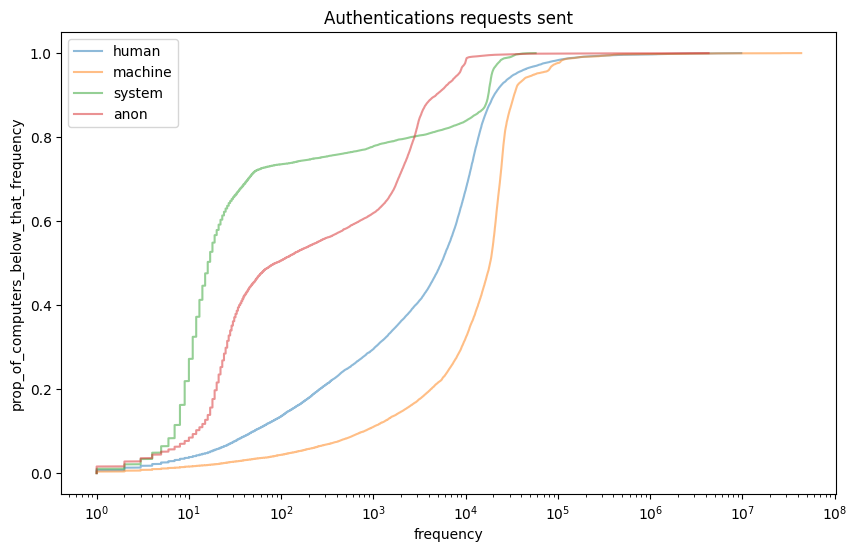

In [6]:
plot_counts(column='source_computer')

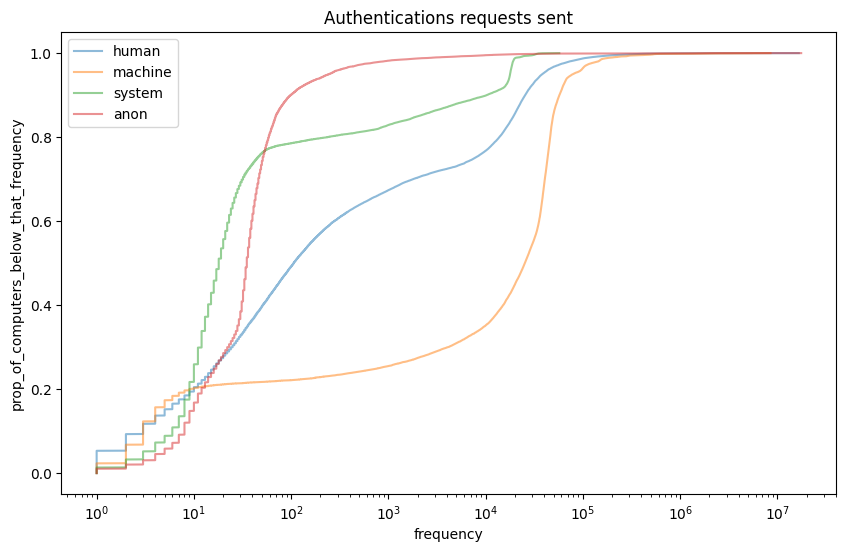

In [7]:
plot_counts(column='source_user@domain')

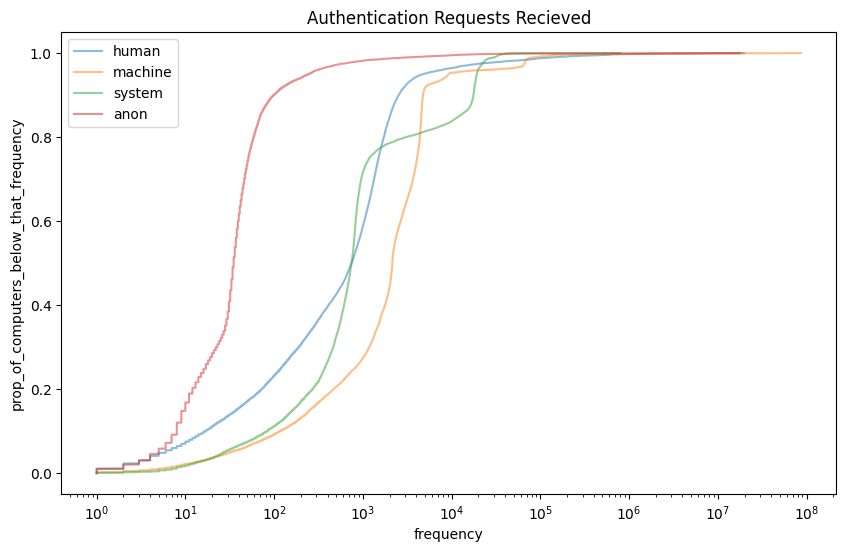

In [8]:
plot_counts(column='destination_computer')

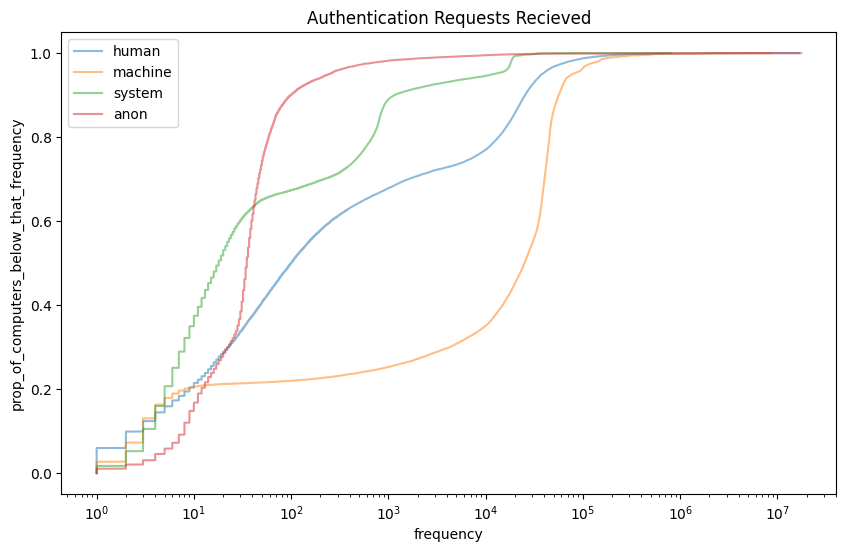

In [9]:
plot_counts(column='destination_user@domain')

In [10]:
df.filter(pl.col('source_user_type') == 'machine').head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure,source_user_type,destination_user_type
str,str,str,str,str,str,str,str,str,str,str
"""1""","""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success""","""machine""","""machine"""
"""1""","""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success""","""machine""","""system"""
"""1""","""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success""","""machine""","""machine"""
"""1""","""C1035$@DOM1""","""C1035$@DOM1""","""C1035""","""C586""","""Kerberos""","""Network""","""LogOn""","""Success""","""machine""","""machine"""
"""1""","""C1035$@DOM1""","""C1035$@DOM1""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success""","""machine""","""machine"""


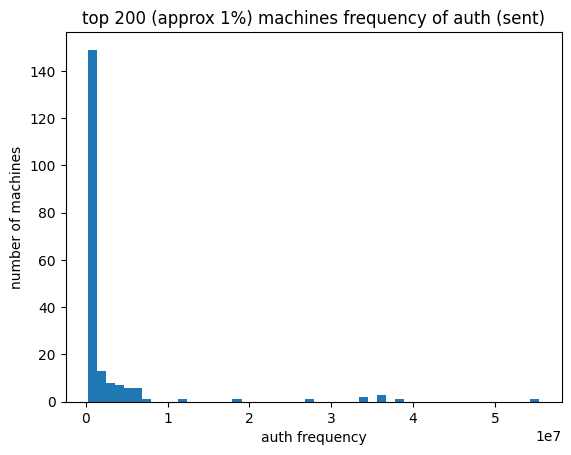

In [162]:
top_pct = source_counts.head(200)
frequencies = top_pct['len'].to_list()
plt.hist(frequencies, bins=50)
plt.title('top 200 (approx 1%) machines frequency of auth (sent)')
plt.xlabel('auth frequency')
plt.ylabel('number of machines')
plt.show()

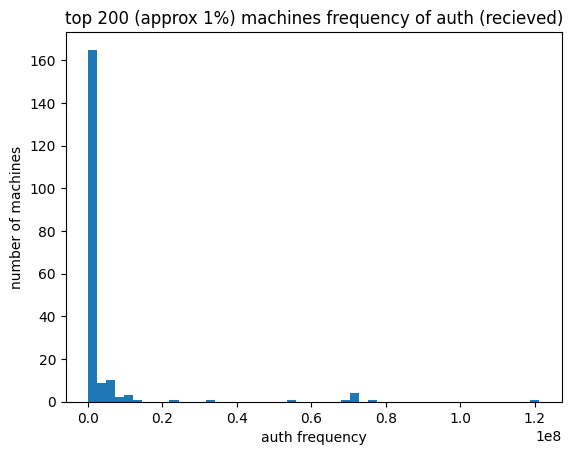

In [16]:
top_pct = destination_counts.head(200)
frequencies = top_pct['len'].to_list()
plt.hist(frequencies, bins=50)
plt.title('top 200 (approx 1%) machines frequency of auth (recieved)')
plt.xlabel('auth frequency')
plt.ylabel('number of machines')
plt.show()

In [ ]:
# 50 machines make up 46% of all source auth flows
source_counts = source_counts.with_columns((pl.col('len').cum_sum() / pl.col('len').sum() *100).alias('cumulative_pct'))
source_counts.head(50)

source_computer,len,cumulative_pct
str,u32,f64
"""C586""",50630165,5.329491
"""C612""",35137579,9.028184
"""C529""",33847062,12.591032
"""C467""",33226389,16.088547
"""C625""",32983300,19.560473
…,…,…
"""C1691""",1502911,45.467105
"""C1183""",1399748,45.614447
"""C2855""",1381941,45.759914


In [ ]:
# Again 50 machines make up 80% of destination flows
destination_counts = destination_counts.with_columns((pl.col('len').cum_sum() / pl.col('len').sum() *100).alias('cumulative_pct'))
destination_counts.head(50)

destination_computer,len,cumulative_pct
str,u32,f64
"""C586""",121232327,11.530228
"""C612""",75369542,18.698514
"""C529""",72674773,25.610504
"""C625""",72161687,32.473696
"""C467""",71962942,39.317985
…,…,…
"""C3034""",1405970,80.163391
"""C3443""",1396036,80.296166
"""C368""",1228988,80.413053


### Human vs machine account identification

In [6]:
print(len(machine_users))
machine_users

17586


['C17705$@DOM1',
 'C25542$@DOM1',
 'C14519$@?',
 'C7652$@?',
 'C24052$@C24052',
 'C8986$@DOM1',
 'C15606$@?',
 'C8688$@DOM1',
 'C19105$@DOM1',
 'C2676$@DOM1',
 'C2058$@DOM1',
 'C7583$@DOM1',
 'C14746$@DOM1',
 'C19744$@DOM1',
 'C21331$@DOM1',
 'C22909$@?',
 'C16249$@?',
 'C3011$@DOM1',
 'C20710$@DOM1',
 'C14676$@DOM1',
 'C5675$@DOM8',
 'C25886$@DOM1',
 'C1577$@DOM1',
 'C2733$@?',
 'C3097$@DOM1',
 'C3307$@?',
 'C17941$@DOM1',
 'C14110$@DOM1',
 'C4106$@DOM1',
 'C12989$@DOM1',
 'C11122$@DOM1',
 'C482$@DOM1',
 'C13492$@DOM1',
 'C1761$@C1761',
 'C24663$@?',
 'C12059$@?',
 'C26253$@?',
 'C16061$@DOM1',
 'C8255$@DOM1',
 'C5325$@DOM1',
 'C24788$@?',
 'C3575$@DOM1',
 'C15388$@DOM1',
 'C877$@DOM1',
 'C22811$@DOM1',
 'C12234$@DOM1',
 'C18244$@DOM1',
 'C19970$@DOM1',
 'C29$@DOM1',
 'C14445$@DOM1',
 'C1381$@DOM267',
 'C25892$@DOM1',
 'C14197$@DOM1',
 'C22980$@?',
 'C13838$@DOM1',
 'C2278$@DOM1',
 'C1361$@DOM1',
 'C1548$@DOM1',
 'C5983$@DOM1',
 'C197$@DOM1',
 'C21706$@?',
 'C5139$@DOM1',
 'C12675$@?'

In [7]:
print(len(human_users))
human_users

62967


['U5582@DOM9',
 'SYSTEM@C6874',
 'SYSTEM@C11656',
 'U2227@DOM1',
 'U637@?',
 'U10137@DOM1',
 'LOCAL SERVICE@C23005',
 'U10295@?',
 'ANONYMOUS LOGON@C23306',
 'U376@DOM9',
 'U10658@DOM1',
 'U5862@DOM1',
 'U10696@DOM1',
 'U6260@DOM9',
 'U11891@DOM1',
 'LOCAL SERVICE@C15558',
 'SYSTEM@C18469',
 'ANONYMOUS LOGON@C26498',
 'U7963@?',
 'U9421@?',
 'ANONYMOUS LOGON@C3019',
 'LOCAL SERVICE@C5771',
 'U805@?',
 'ANONYMOUS LOGON@C10888',
 'U2321@DOM1',
 'U8849@C22031',
 'U6177@DOM21',
 'NETWORK SERVICE@C5855',
 'SYSTEM@C22220',
 'U8693@?',
 'U5666@DOM9',
 'U6619@DOM1',
 'U11288@?',
 'SYSTEM@C19930',
 'U12389@DOM1',
 'U1463@DOM1',
 'U8763@DOM1',
 'SYSTEM@C23783',
 'U1006@DOM1',
 'ANONYMOUS LOGON@C11059',
 'U8818@DOM1',
 'U3233@?',
 'U4330@DOM9',
 'U4448@DOM1',
 'SYSTEM@C20013',
 'U7465@DOM9',
 'U5065@DOM1',
 'NETWORK SERVICE@C3974',
 'SYSTEM@C10616',
 'U9855@?',
 'U1375@DOM1',
 'SYSTEM@C15032',
 'U2415@?',
 'ANONYMOUS LOGON@C24071',
 'U4476@?',
 'U2921@?',
 'SYSTEM@C14891',
 'U10724@DOM9',
 'U5065

In [29]:
df.select('success/failure').unique().collect()

success/failure
str
"""Fail"""
"""Success"""


In [31]:
df.filter((pl.col('source_user@domain').is_in(machine_users)) & (pl.col('success/failure') == 'Fail')).collect().head()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure,hash
str,str,str,str,str,str,str,str,str,u64
"""4""","""C1149$@DOM1""","""U1325@DOM1""","""C1149""","""C1149""","""Negotiate""","""Batch""","""LogOn""","""Fail""",14834276115038065987
"""5""","""C1846$@DOM1""","""U86@DOM1""","""C1846""","""C1846""","""Negotiate""","""Batch""","""LogOn""","""Fail""",4319291380879941793
"""6""","""C3073$@DOM1""","""C3073$@DOM1""","""C3073""","""C3073""","""?""","""?""","""TGT""","""Fail""",11397060732021792
"""8""","""C1654$@DOM1""","""U86@DOM1""","""C1654""","""C1654""","""Negotiate""","""Batch""","""LogOn""","""Fail""",1282423137767563644
"""33""","""C2096$@?""","""C2096$@?""","""C457""","""C457""","""?""","""?""","""TGT""","""Fail""",5426221698002210221


In [33]:
# 
df2 = df.with_columns(
    pl.col('source_user@domain').is_in(human_users).alias('human_source')
    ).with_columns(pl.col('destination_user@domain').is_in(human_users).alias('human_destination')
    ).group_by(['human_source', 'human_destination', 'success/failure']).len().collect()

In [35]:
df2.sort(by='len', descending=True)

human_source,human_destination,success/failure,len
bool,bool,str,u32
false,false,"""Success""",620471152
true,true,"""Success""",405198267
true,true,"""Fail""",9835150
false,true,"""Success""",9722909
true,false,"""Success""",3197823
false,false,"""Fail""",2724811
false,true,"""Fail""",274631
true,false,"""Fail""",5716


In [49]:
df2.with_columns((pl.col('len') / pl.col('len').sum().over(['human_source', 'human_destination'])).alias('pct_sucess')).filter(
    pl.col('success/failure') == 'Success').sort(by='pct_sucess', descending=True).rename({'len' : 'Number_Successes'})

human_source,human_destination,success/failure,Number_Successes,pct_sucess
bool,bool,str,u32,f64
true,false,"""Success""",3197823,0.998216
false,false,"""Success""",620471152,0.995628
true,true,"""Success""",405198267,0.976303
false,true,"""Success""",9722909,0.97253


In [10]:
# How often does a user talk to itself
df.filter(
    (pl.col('source_user@domain') == pl.col('destination_user@domain'))).group_by('human_source').len().collect()

human_source,len
bool,u32
false,622983269
true,411559302


In [166]:
# Key metrics for human and machine users mean median variance etc

### Checking the variance in flows over time

In [80]:
# Random sampled user plot

def sample_user(machine):
    """
    Samples a machine or human user and returns interaction times
    """
    if machine == True:
        user_number = np.random.randint(0, len(machine_users))
        user = machine_users[user_number]
    else:
        user_number = np.random.randint(0, len(human_users))
        user = human_users[user_number]

    user_frame = df.filter(pl.col('source_user@domain') == user).collect()
    times = user_frame.select('time').to_series().to_list()
    times = [int(t) for t in times]
    return user_frame, times

In [ ]:
def plot_times(times, xlim, vert_line = None):
    fig, ax = plt.subplots(figsize=(12, 2))
    ax.eventplot(times, orientation="horizontal")
    ax.set_yticks([])
    ax.set_xlabel("Time")
    ax.set_xlim(0, xlim)
    if vert_line is not None:
        offset = vert_line[0]
        step = vert_line[1]
        for x in range(0, xlim, step):
            ax.axvline(x-offset, color="red", linewidth=0.8, alpha=0.6)
    plt.show()

In [141]:
# Sample a new set of machine times
_, times = sample_user(machine=False)
print(len(times))

22460


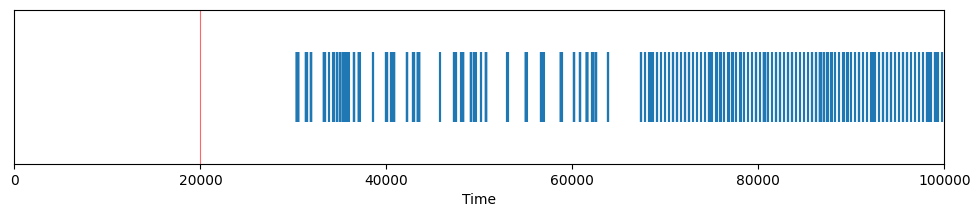

In [144]:
# Max time in df is 5011199

v = None
v = (50000, 70000)
xlim = 100000
plot_times(times, xlim = xlim, vert_line=v)

In [52]:
# Random sampled machines flow plot and variance
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure
str,str,str,str,str,str,str,str,str
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
"""1""","""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
"""1""","""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
"""1""","""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


In [ ]:
# Checking for duplicates
df.group_by(['time', 'source_user@domain', 'destination_user@domain', 'source_computer', 'destination_computer', 'authentication_type', 'logon_type', 'authentication_orientation', 'success/failure']).len().sort(by='len').head().collect()

### Noteworthy findings

#### Section 1
No duplicates found


Clear distinction between human and machine users in the dataframe dermakated by $
Clear periodic behaviour observed for some machine users
Multiple requests made within identical time periods common

#### Example of clearly regular machine behaviour

![Output plot](savedplots/machine_plot1.png)
![Output plot](savedplots/machine_plot2.png)

### Typical examples of human behaviour
Less regularity is typically observed

![Output plot](savedplots/human_user1.png)
![Output plot](savedplots/human_user2.png)

In [ ]:
# Example of multiple requests in the same window
_.head()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,success/failure
str,str,str,str,str,str,str,str,str
"""1422360""","""C23653$@DOM1""","""C23653$@DOM1""","""C23653""","""C23653""","""?""","""?""","""TGT""","""Success"""
"""1422360""","""C23653$@DOM1""","""C23653$@DOM1""","""C23653""","""C528""","""?""","""?""","""TGS""","""Success"""
"""1422360""","""C23653$@DOM1""","""C23653$@DOM1""","""C23653""","""C528""","""Kerberos""","""Network""","""LogOn""","""Success"""
"""1422360""","""C23653$@DOM1""","""C23653$@DOM1""","""C23653""","""TGT""","""?""","""?""","""TGS""","""Success"""
"""1422371""","""C23653$@DOM1""","""C23653$@DOM1""","""C528""","""C528""","""?""","""Network""","""LogOff""","""Success"""


### A note on domains, machines and system processes

Domains are basically big databases of usernames and passwords and permissions on a windows server. You authenticate against the domain and then are granted permissions to do stuff by the domain controler.

User activity is usually run with a user account. 

Computer accounts also exist and can be used by appications for running processes automated and not.

Windows also provides some built in accounts which can be harnessed by applications. These are the system accounts the domain here is the machine the system account is running on.

Anonymous logons are sessions where Windows did not associate the connection with a named authenticated identity. The underlying actor could be a user process, machine process, system process, or misconfigured service.

#### A note on source and destination users and machines

- source user = who you are coming from
- destination user = who you are logging/logging off in as
- source computer = where the login/logoff request comes from
- destination computer = where you are logging in /logging off too, e.g. accessing a file on a server requires you to authenticate onto a different machine

### Cleaning + Pipeline to do

- Filter the anon users as these can correspond to many different types of behaviour
- Maybe filter the system users out too
- Operate on a user not a computer level as multiple different users can share the same machine making messy behaviour on a machine level with mixture between human and machine time series observed.
- For each user, we estimate a mean and variance for every bin. These estimates are then smoothed towards cluster-average values. We first sort each user’s bin-level parameters to form a user-specific distribution. We then build a cluster-level reference distribution by averaging parameters at the same sorted position across users in the cluster. Each user’s parameter is then smoothed towards the corresponding value in this cluster distribution.
